In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas.api.types as ptypes
from wordcloud import WordCloud
from collections import Counter
import sqlalchemy as sql
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
import prettytable
import openpyxl 
import plotly.express as px
import nbformat

### Business Understanding
This is an analysis of the surgical camp data that happened on   ,at the Vihiga Teaching and Referral Hospital.The data will be cleaned and analysed to bring out insights and trends for informed decision making.


### Data Exploration

In [106]:
#loading the dataset and drop sensitive columns like OP_NO and Phone_no
surg_data=pd.read_excel(r"C:\Users\user\OneDrive\Desktop\surgical camp 2\Habil.xlsx")
surg_data=surg_data.drop(columns=['Op_no','Phone_no'])
surg_data.head(20)

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure
0,2025-10-26,M,39,Emuhaya,Vihiga,Hernia,Yes,NaN,VCRH,NaN,Hernia,excision
1,2025-10-26,M,69,NaN,Vihiga,Hernia,Yes,NaN,VCRH,NaN,Hernia,excision
2,2025-10-26,M,54,Kisumu,Kisumu,Hernia,Yes,NaN,VCRH,NaN,VIL,NaN
3,2025-10-26,F,39,NaN,Kakamega,Excision,No,NaN,VCRH,NaN,Lipoma,excision
4,2025-10-26,F,61,Vihiga,Vihiga,Lipoma,No,NaN,VCRH,NaN,Lipoma,excision
5,2025-10-26,F,26,Emuhaya,Vihiga,Keloids,No,NaN,VCRH,NaN,Keloids,NaN
6,2025-10-26,F,17,Vihiga,Vihiga,Ganglion cysts,Yes,NaN,VCRH,NaN,Ganglion cysts,NaN
7,2025-10-26,M,56,Vihiga,Vihiga,Excision,No,NaN,VCRH,NaN,Lipoma,excision
8,2025-10-26,F,52,Vihiga,Vihiga,Umbilical,No,NaN,VCRH,NaN,Umbilical,NaN
9,2025-10-26,M,49,Sabatia,Vihiga,Regional mass,No,NaN,NaN,NaN,Regional mass,NaN


----

The dataset has blank records,which were not filled especially in columns:
'Ever visited hospital for this condition'
'If yes what was the outcome'
'Which hospital'
'If no why '
This poses a challenge in analysis as the indicator was to be used to 
ascertain the medical history of
the patient and any previous intervention


In [107]:
#looking at the dataset info
#the dataset has a total of 134 entries and null values in various indicators
surg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   DATE                                      134 non-null    datetime64[ns]
 1   Sex                                       139 non-null    object        
 2   Age                                       130 non-null    object        
 3   Subcounty                                 137 non-null    object        
 4   County                                    139 non-null    object        
 5   Complain                                  129 non-null    object        
 6   Ever visited hospital for this condition  134 non-null    object        
 7   If yes what was the outcome               10 non-null     object        
 8   Which hospital                            24 non-null     object        
 9   If no why                       

---

There were also missing values in age,which were sorted out

In [108]:
#the dataset has values with missing age 
surg_data['Age'].isna()

0      False
1      False
2      False
3      False
4      False
       ...  
134    False
135    False
136    False
137    False
138    False
Name: Age, Length: 139, dtype: bool

---

Upon further analysis of age it was noted some ages were entered as alphanumeric (2months),
this would make it impossible to analyse as numeric.
Therefore the ages were rounded up to 1 year for the purpose of analysis,since the ages were in 
terms of years and not months

In [109]:
#unique values at age
pd.unique(surg_data['Age'])

#some age are alphanumeric '2months' which will make it hard to analyze numeric ages,
#we will round them to 1 year for easy analysis

array([39, 69, 54, 61, 26, 17, 56, 52, 49, 62, 51, 45, 70, nan, 38, 14, 8,
       23, 42, 41, 21, 53, 27, 48, 44, 65, 34, '2M0NTHS', 3, 79, 73, 1,
       43, 16, 64, 66, 40, 57, 6, 30, 25, 31, 50, 37, 13, 47, 80, 36, 60,
       9, 72, 55, 35, 32, 82, 22, 5, 33, 63, 7], dtype=object)

In [110]:
#replacing the 2months cases to 1 year
surg_data.loc[surg_data['Age']=='2M0NTHS','Age']=1

In [111]:
#replacing the 2months cases to 1 year
surg_data.loc[surg_data['Age']=='2MONTHS','Age']=1

In [150]:
#unique values at age
#noted we still have a nan which will be sorted out
pd.unique(surg_data['Age'])

array([39, 69, 54, 61, 26, 17, 56, 52, 49, 62, 51, 45, 70, 38, 14,  8, 23,
       42, 41, 21, 53, 27, 48, 44, 63, 80, 55, 65, 34,  1,  3, 79, 73, 43,
       16, 64, 66, 40, 57,  6, 30, 25, 31, 50, 37, 13, 47, 36, 60,  9, 72,
       35, 32, 82, 22,  5, 33,  7])

---

In [ ]:
#getting the descriptive statistics for the numerical columns,
# unfortunately age has some categorical values
surg_data.describe()

,DATE,Age,Sex_num
count,134,139.000000,139.000000
mean,2025-10-27 15:56:25.074626816,43.237410,0.669065
min,2025-10-26 00:00:00,1.000000,0.000000
25%,2025-10-27 00:00:00,30.500000,0.000000
50%,2025-10-28 00:00:00,45.000000,1.000000
75%,2025-10-28 00:00:00,56.500000,1.000000
max,2025-10-30 00:00:00,82.000000,1.000000
std,NaN,20.330809,0.472252


---

### Exploratory Data Analysis

The dataset has a total entry of 139 records which comensuarte with the number that were 
operated

In [159]:
#the shape of the dataset,it has 139 rows with 11 columns
surg_data.shape

(139, 13)

In [160]:
#column names in the dataset
surg_data.columns

Index(['DATE', 'Sex', 'Age', 'Subcounty', 'County', 'Complain',
       'Ever visited hospital for this condition',
       'If yes what was the outcome', 'Which hospital', 'If no why',
       'Diagnosis', 'Procedure', 'Sex_num'],
      dtype='object')

In [161]:
#the number of columns with null values
surg_data.isna().sum()

DATE                                          5
Sex                                           0
Age                                           0
Subcounty                                     2
County                                        0
Complain                                     10
Ever visited hospital for this condition      5
If yes what was the outcome                 129
Which hospital                              115
If no why                                   133
Diagnosis                                     2
Procedure                                    20
Sex_num                                       0
dtype: int64

In [162]:
#getting the mean values of columns having empty rows(null values)
surg_data.isna().mean()*100

DATE                                         3.597122
Sex                                          0.000000
Age                                          0.000000
Subcounty                                    1.438849
County                                       0.000000
Complain                                     7.194245
Ever visited hospital for this condition     3.597122
If yes what was the outcome                 92.805755
Which hospital                              82.733813
If no why                                   95.683453
Diagnosis                                    1.438849
Procedure                                   14.388489
Sex_num                                      0.000000
dtype: float64

In [163]:
#checking if indicator 'sex' has only two variables (M/F) and that age has no object category
sex=surg_data['Sex'].unique()
#age_cat=surg_data['Age'].dtypes()
age_cat=ptypes.is_categorical_dtype(surg_data['Age'])
print(f'The unique data in sex are :{sex},while are there categorical data in age? {age_cat}');

The unique data in sex are :['m' 'f'],while are there categorical data in age? False


C:\Users\user\AppData\Local\Temp\ipykernel_1056\1046034720.py:4: DeprecationWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead



In [164]:
#unique values in diagnosis
surg_data['Diagnosis'].unique()

array(['hernia', 'vil', 'lipoma', 'keloids', 'ganglion cysts',
       'umbilical', 'regional mass', 'occipital swelling', 'goitre', nan,
       'face/neck kelloid', 'inguinal hernia', 'supraumbilical hernia',
       'inguinoscrotal hernia', 'kelloid', 'cyst', 'umbilical hernia',
       'face reconstruction', 'cleft lip', 'fibroma', 'cleft palate',
       'ingunosacral hernia', 'right inguinal hernia',
       'submandibular swelling', 'multinodular goitre', 'maxilliary mass',
       'thyroid', 'kelloids', 'ganglion cyst', 'regional head mass ',
       'inguinosacral hernia', 'neck mass', 'kneck swelling',
       'thyroid swelling', 'maxilliary swelling', 'adenoiditis',
       'hydrocele', 'thyroid swelling goitre', 'neck swelling',
       'inguino hernia', 'ganglion', 'cryptochidism', 'epigastric hernia',
       'hypertrophy adenoids', 'tongue lession', 'swelling',
       'jaw dislocation', 'enlarged thyroid gland'], dtype=object)

In [165]:
surg_data

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NaT,f,63,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,jaw dislocation,close reduction of bilateral mandibular condyl...,1
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1
136,NaT,m,65,ebusiratsi,vihiga,NaN,NaN,NaN,NaN,NaN,epigastric hernia,herniorraphy,0
137,NaT,f,27,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,enlarged thyroid gland,lobectomy,1


from the entries 4 patients missed diagnosis,this will be solved by sourcing the records from 
theatre list

In [166]:
#patients missing diagnoses

surg_data[surg_data['Diagnosis'].isna()]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num
13,2025-10-26,f,70,mwanza,machakos,NaN,yes,NaN,NaN,NaN,NaN,NaN,1
16,2025-10-26,f,38,sabatia,vihiga,NaN,no,NaN,NaN,NaN,NaN,NaN,1


---

For uniformity of words,the records will be transformed to lowercase

In [167]:
#convert all the  dataset into lower case for uniformity


#function to convert to lower case
def lower(indicator):
    return indicator.str.lower()


surg_data['Diagnosis']=lower(surg_data['Diagnosis'])
surg_data['Sex']=lower(surg_data['Sex'])
surg_data['Subcounty']=lower(surg_data['Subcounty'])
surg_data['County']=lower(surg_data['County'])
surg_data['Complain']=lower(surg_data['Complain'])
surg_data['Ever visited hospital for this condition']=lower(surg_data['Ever visited hospital for this condition'])
surg_data['If yes what was the outcome']=lower(surg_data['If yes what was the outcome'])
surg_data['Which hospital']=lower(surg_data['Which hospital'])
surg_data['If no why']=lower(surg_data['If no why'])



----

We have records that are missing from the dataset,this will be filled by use of functio

In [168]:
#function to edit missing values 
def fill_missing_row(surg_data,row,column,value):
    surg_data.loc[row,column]=value
    return surg_data
    



In [169]:
#the dataset had many missing values across the different indicators
#therefore more data was sourced from theatre list and reconciled
fill_missing_row(surg_data,12,'Diagnosis','goitre')
fill_missing_row(surg_data,15,'Age',52)
fill_missing_row(surg_data,15,'Diagnosis','face/neck kelloid')
fill_missing_row(surg_data,34,'Age',56)
fill_missing_row(surg_data,36,'Age',63)
fill_missing_row(surg_data,38,'Age',54)
fill_missing_row(surg_data,40,'Age',55)
fill_missing_row(surg_data,37,'Age',80)
fill_missing_row(surg_data,62,'Diagnosis','maxilliary mass')
fill_missing_row(surg_data,57,'Diagnosis','ingunosacral hernia')
fill_missing_row(surg_data,69,'Diagnosis','inguinosacral hernia')
fill_missing_row(surg_data,74,'Diagnosis','inguinosacral hernia')
fill_missing_row(surg_data,77,'Diagnosis','inguinosacral hernia')
fill_missing_row(surg_data,104,'Diagnosis','supraumbilical hernia')
fill_missing_row(surg_data,105,'Diagnosis','supraumbilical hernia')
fill_missing_row(surg_data,106,'Diagnosis','inguino hernia')
fill_missing_row(surg_data,117,'Diagnosis','epigastric hernia')
fill_missing_row(surg_data,125,'Diagnosis','inguino hernia')










,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NaT,f,63,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,jaw dislocation,close reduction of bilateral mandibular condyl...,1
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1
136,NaT,m,65,ebusiratsi,vihiga,NaN,NaN,NaN,NaN,NaN,epigastric hernia,herniorraphy,0
137,NaT,f,27,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,enlarged thyroid gland,lobectomy,1


In [227]:
#replace mispelt 'kelloid' with the right spelling 'keloid
surg_data.loc[surg_data['Diagnosis'].str.contains('kelloid|keloids', na=False), 'Diagnosis'] = 'keloid'


The remaining missing age that could not be located will be filled by use of mode

In [228]:
#the remiaining null values will be filled with mode
surg_data['Age']=surg_data['Age'].fillna(surg_data['Age'].mode()[0])

----

In [229]:
#looking at the new dataset
surg_data

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,0.077334,34.614690
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,-4.220670,29.082704
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,-0.102911,34.754176
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1,-4.220670,29.082704
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1,0.081928,34.708420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NaT,f,63,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,jaw dislocation,close reduction of bilateral mandibular condyl...,1,NaN,NaN
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1,0.152115,34.703461
136,NaT,m,65,ebusiratsi,vihiga,NaN,NaN,NaN,NaN,NaN,hernia,herniorraphy,0,0.087961,34.637680
137,NaT,f,27,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,enlarged thyroid gland,lobectomy,1,NaN,NaN


----

Patients residence in bargraph,patients came from vihiga county,followed with kakamega.
however we have patients that came from as far as mwanza in machakos and rusinga

<Axes: ylabel='Subcounty'>

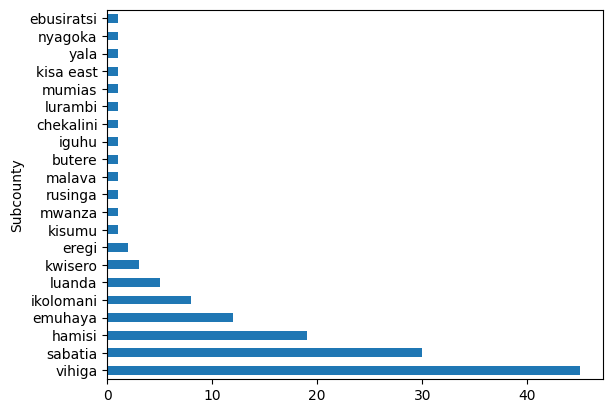

In [276]:
#count of the patients residencein bargraph
surg_data['Subcounty'].value_counts().plot(kind='barh')

----

majority of the patients answered 'No' to 'ever visited a health facility'.The purpose of this indicator 
was to gain insight to health seeking behaviour.

<Axes: xlabel='Ever visited hospital for this condition'>

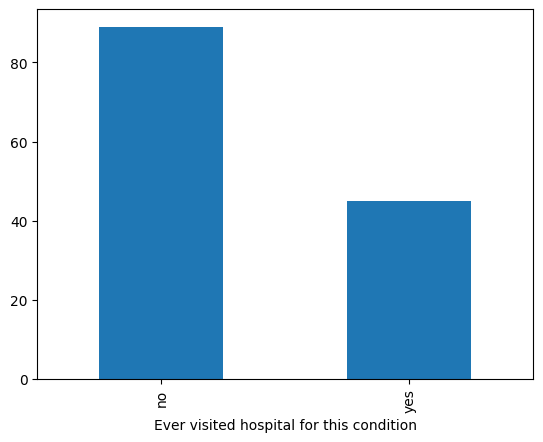

In [231]:
#visualization for patients who ever visited a health facility to be treated for that condition prior 
#to this camp
surg_data['Ever visited hospital for this condition'].value_counts().plot(kind='bar')

45(32% of those operated) patients responded yes to ever visisting a health facility,with 15(33%) being males and 67% being females

In [265]:
surg_data[surg_data['Ever visited hospital for this condition']=='yes']

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,0.077334,34.614690
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,-4.220670,29.082704
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,-0.102911,34.754176
6,2025-10-26,f,17,vihiga,vihiga,ganglion cysts,yes,NaN,vcrh,NaN,ganglion cysts,NaN,1,0.081928,34.708420
12,2025-10-26,f,45,sabatia,vihiga,NaN,yes,NaN,NaN,NaN,goitre,NaN,1,0.112839,34.749590
13,2025-10-26,f,70,mwanza,machakos,NaN,yes,NaN,NaN,NaN,NaN,NaN,1,-3.099866,39.563422
14,2025-10-26,f,70,sabatia,vihiga,hernia,yes,NaN,NaN,NaN,hernia,NaN,1,0.112839,34.749590
15,2025-10-26,m,52,butere,kakamega,NaN,yes,NaN,NaN,NaN,keloid,NaN,0,0.216308,34.498130
19,2025-10-27,m,8,emuhaya,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,0,0.077334,34.614690
21,2025-10-27,m,56,sabatia,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,0,0.112839,34.749590


89 (64%) of the patients that were operated on answered 'no ' to ever visiting a health facility,with 16(18%) being males and 73(82%) being females

In [266]:
surg_data[surg_data['Ever visited hospital for this condition']=='no']

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1,-4.220670,29.082704
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1,0.081928,34.708420
5,2025-10-26,f,26,emuhaya,vihiga,keloids,no,NaN,vcrh,NaN,keloid,NaN,1,0.077334,34.614690
7,2025-10-26,m,56,vihiga,vihiga,excision,no,NaN,vcrh,NaN,lipoma,excision,0,0.081928,34.708420
8,2025-10-26,f,52,vihiga,vihiga,umbilical,no,NaN,vcrh,NaN,umbilical,NaN,1,0.081928,34.708420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2025-10-30,m,63,emuhaya,vihiga,neck swelling,no,NaN,NaN,NaN,neck swelling,excision,0,0.077334,34.614690
130,2025-10-30,f,70,sabatia,vihiga,lipoma,no,NaN,NaN,NaN,lipoma,excision,1,0.112839,34.749590
131,2025-10-30,m,7,sabatia,vihiga,swelling,no,NaN,NaN,NaN,swelling,excision,0,0.112839,34.749590
132,2025-10-30,f,49,vihiga,vihiga,lipoma,no,NaN,NaN,NaN,lipoma,excision,1,0.081928,34.708420


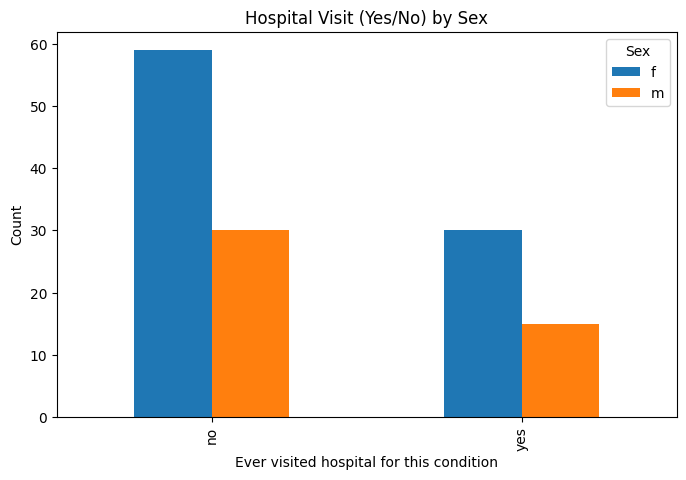

In [232]:
# Create a frequency table grouped by Sex
counts = surg_data.groupby(['Ever visited hospital for this condition', 'Sex']).size().unstack()

counts.plot(kind='bar', figsize=(8,5))

plt.xlabel('Ever visited hospital for this condition')
plt.ylabel('Count')
plt.title('Hospital Visit (Yes/No) by Sex')
plt.legend(title='Sex')
plt.show()

----

From the wordcloud 'Lipoma' and 'Hernio ' have come out very strongly as leading diagnoses
followed by kelloids.
While 'Excision' and 'herniorraphy' were the leading procedures done

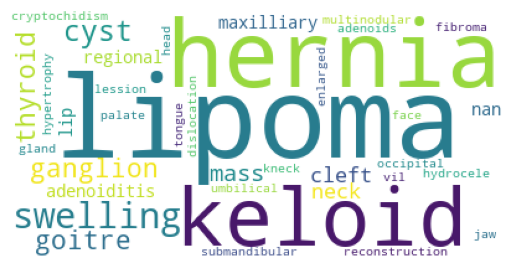

In [233]:
#visualization for conditions on wordcloud
diagnoses= " ".join(surg_data['Diagnosis'].astype(str))
wordc=WordCloud(background_color='white').generate(diagnoses)
plt.imshow(wordc)
plt.axis('off')
plt.show()

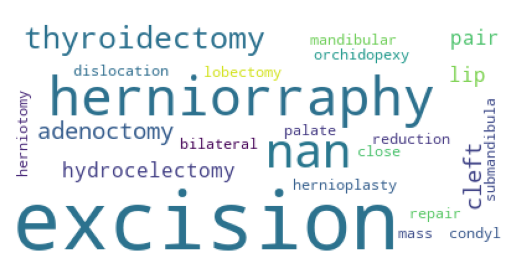

In [234]:
#visualization for procedures on wordcloud
procedure = " ".join(surg_data['Procedure'].astype(str))
wordc=WordCloud(background_color='white').generate(procedure)
plt.imshow(wordc)
plt.axis('off')
plt.show()

----

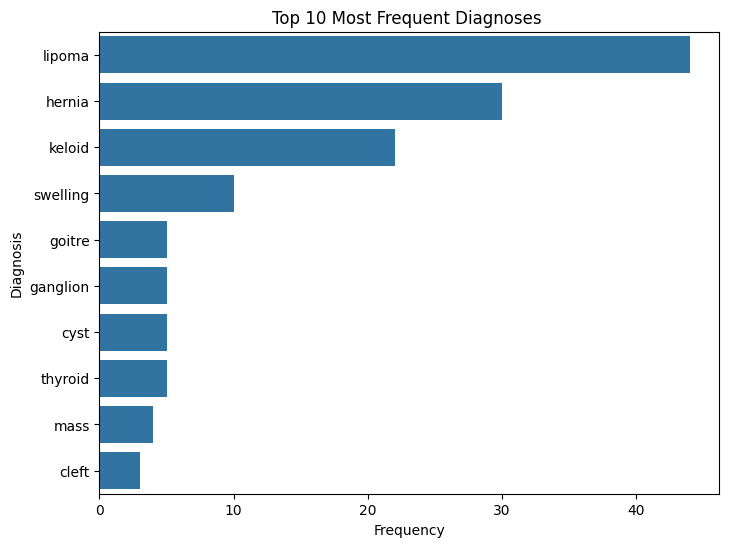

In [238]:
#visualization for conditions in a horizontal bargraph

surg_data.loc[surg_data['Diagnosis'].str.contains('hernia', na=False), 'Diagnosis'] = 'hernia'


# Combine and count words in Diagnosis column
diagnoses = " ".join(surg_data['Diagnosis'].astype(str))
word = diagnoses.split()
diagnoses_freq = Counter(word)

# Convert to dataframe and sort
df = pd.DataFrame(diagnoses_freq.items(), columns=['word', 'count']).sort_values(by='count', ascending=False)

# Select top 15
top15 = df.head(10)

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x='count', y='word', data=top15)

plt.title('Top 10 Most Frequent Diagnoses ')
plt.xlabel('Frequency')
plt.ylabel('Diagnosis')
plt.show()


-----

The median (central line) is around 45–50 years
Shows that half of the patients are below ~50, half above.
25% of patients are younger than ~35

50% are between 35 and 60

25% are older than ~60
Lower whisker extends down to about 1 year

Upper whisker extends up to about 82 years

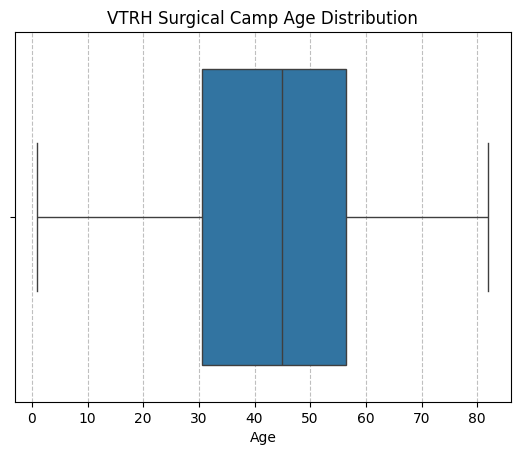

In [268]:
#boxplot for age distribution
sns.boxplot(x='Age',data=surg_data)
plt.title('VTRH Surgical Camp Age Distribution')
plt.grid(axis='x',linestyle='--',alpha=0.5,color='grey')

the attendance by sex was 93 female (67%) and 46 males (33%)

In [ ]:
#the number of patients by sex grouped by age
surg_data.groupby('Sex')['Age'].count()

Sex
f    93
m    46
Name: Age, dtype: int64

In [241]:
#patients by sex with their age statistics
surg_data.groupby('Sex').agg({
    'Age': ['mean', 'median', 'min', 'max']
})

Age               
          mean median min max
Sex                          
f    41.774194   42.0   1  82
m    46.195652   53.0   1  80

jittered scatter plot was used in order to spread the points

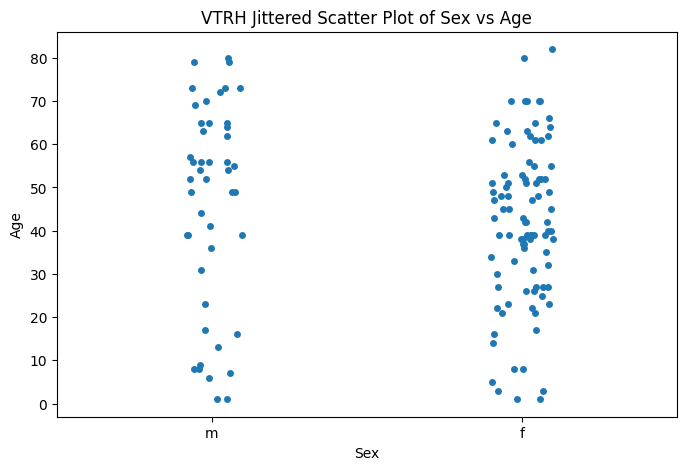

In [269]:

#jittered scatter plot
plt.figure(figsize=(8,5))

sns.stripplot(data=surg_data, x='Sex', y='Age', jitter=True)

plt.title('VTRH Jittered Scatter Plot of Sex vs Age')
plt.show()

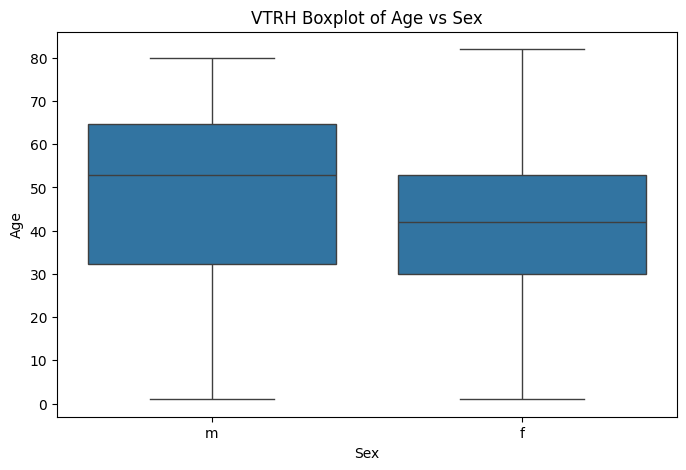

In [270]:

plt.figure(figsize=(8,5))

sns.boxplot(data=surg_data, x='Sex', y='Age')

plt.title('VTRH Boxplot of Age vs Sex')
plt.show()

In [244]:
surg_data

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,0.077334,34.614690
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,-4.220670,29.082704
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,-0.102911,34.754176
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1,-4.220670,29.082704
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1,0.081928,34.708420
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NaT,f,63,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,jaw dislocation,close reduction of bilateral mandibular condyl...,1,NaN,NaN
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1,0.152115,34.703461
136,NaT,m,65,ebusiratsi,vihiga,NaN,NaN,NaN,NaN,NaN,hernia,herniorraphy,0,0.087961,34.637680
137,NaT,f,27,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,enlarged thyroid gland,lobectomy,1,NaN,NaN


In [245]:
surg_data.columns

Index(['DATE', 'Sex', 'Age', 'Subcounty', 'County', 'Complain',
       'Ever visited hospital for this condition',
       'If yes what was the outcome', 'Which hospital', 'If no why',
       'Diagnosis', 'Procedure', 'Sex_num', 'Latitude', 'Longitude'],
      dtype='object')

A total of 15 male(11%) patients have a history of attending a health facility.
Of these 15 ,5 attended vcrh prior,while 1 attended sabatia and the other 1 attended Yala.13 of the patients hail from vihiga county.and the majority of the cases were hernia.

In [246]:
#the number of male patients that have visited hospital before for that condition
surg_data[(surg_data['Sex']=='m')& (surg_data['Ever visited hospital for this condition']=='yes')]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,0.077334,34.614690
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,-4.220670,29.082704
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,-0.102911,34.754176
15,2025-10-26,m,52,butere,kakamega,NaN,yes,NaN,NaN,NaN,keloid,NaN,0,0.216308,34.498130
19,2025-10-27,m,8,emuhaya,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,0,0.077334,34.614690
21,2025-10-27,m,56,sabatia,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,0,0.112839,34.749590
34,2025-10-27,m,56,vihiga,vihiga,lipoma,yes,NaN,NaN,NaN,lipoma,excision,0,0.081928,34.708420
35,2025-10-27,m,39,vihiga,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,0,0.081928,34.708420
67,2025-10-28,m,56,emuhaya,vihiga,hernia,yes,NaN,yala,NaN,hernia,herniorraphy,0,0.077334,34.614690
75,2025-10-28,m,6,hamisi,vihiga,hernia,yes,reccurent,knh,reccurent,hernia,herniorraphy,0,0.089835,34.832596


In [247]:
#the number of male patients that have visited hospital before for that condition
len(surg_data[(surg_data['Sex']=='m')& (surg_data['Ever visited hospital for this condition']=='yes')])

15

the number of female patients that had previously attended a health facility with the related condition were 30(22%),of those who gave response on the outcome,problem with SHA and finance were one of the reason.those who had attended vcrh were 5,lipoma came out strongly as a leading case ,followed by kelloid.however it note also goitre and thyroid swelling was more prevalent to female compared to males

In [248]:
#the number of female clients that have ever visited a facility 
surg_data[(surg_data['Sex']=='f')& (surg_data['Ever visited hospital for this condition']=='yes')]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
6,2025-10-26,f,17,vihiga,vihiga,ganglion cysts,yes,NaN,vcrh,NaN,ganglion cysts,NaN,1,0.081928,34.708420
12,2025-10-26,f,45,sabatia,vihiga,NaN,yes,NaN,NaN,NaN,goitre,NaN,1,0.112839,34.749590
13,2025-10-26,f,70,mwanza,machakos,NaN,yes,NaN,NaN,NaN,NaN,NaN,1,-3.099866,39.563422
14,2025-10-26,f,70,sabatia,vihiga,hernia,yes,NaN,NaN,NaN,hernia,NaN,1,0.112839,34.749590
36,2025-10-27,f,63,chekalini,kakamega,lipoma,yes,NaN,NaN,NaN,lipoma,excision,1,0.621880,34.907578
45,2025-10-27,f,65,luanda,vihiga,lipoma,yes,NaN,NaN,NaN,lipoma,excision,1,0.019207,34.596767
48,2025-10-27,f,1,vihiga,vihiga,cleft lip,yes,NaN,NaN,NaN,cleft lip,cleft lip pair,1,0.081928,34.708420
49,2025-10-27,f,70,sabatia,vihiga,hernia,yes,NaN,NaN,NaN,hernia,herniorraphy,1,0.112839,34.749590
50,2025-10-27,f,48,sabatia,vihiga,fibroma,yes,NaN,NaN,NaN,fibroma,excision,1,0.112839,34.749590
51,2025-10-27,f,1,vihiga,vihiga,cleft lip,yes,NaN,NaN,NaN,cleft lip,cleft lip pair,1,0.081928,34.708420


of the female clients that had visited hospital prior their outcome was that the condition was recurring

In [249]:
#patients that have prior visited a health facility and their outcome
surg_data[(surg_data['Ever visited hospital for this condition']=='yes') & (surg_data['If yes what was the outcome'].notna())]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
75,2025-10-28,m,6,hamisi,vihiga,hernia,yes,reccurent,knh,reccurent,hernia,herniorraphy,0,0.089835,34.832596
76,2025-10-28,f,30,vihiga,vihiga,keloids,yes,on medication,vcrh,NaN,keloid,excision,1,0.081928,34.708420
83,2025-10-28,f,61,sabatia,vihiga,kneck swelling,yes,reffered to vcrh,NaN,NaN,kneck swelling,submandibula mass excision,1,0.112839,34.749590
87,2025-10-28,f,3,emuhaya,vihiga,swelling,yes,nairobi,NaN,NaN,maxilliary swelling,excision,1,0.077334,34.614690
90,2025-10-28,f,47,hamisi,vihiga,lipoma,yes,refferal to jootrh,NaN,NaN,lipoma,excision,1,0.089835,34.832596
97,2025-10-28,f,37,emuhaya,vihiga,lipoma,yes,reccurent,vcrh,NaN,lipoma,excision,1,0.077334,34.614690
105,2025-10-29,f,38,hamisi,vihiga,hernia,yes,refferal,hamisi,NaN,hernia,herniorraphy,1,0.089835,34.832596
117,2025-10-29,f,42,ikolomani,kakamega,hernia,yes,reccerent,vcrh,NaN,hernia,herniorraphy,1,0.193729,34.695465
119,2025-10-29,f,33,kwisero,kakamega,keloids,yes,reccurent,kakamega,NaN,keloid,excision,1,NaN,NaN
124,2025-10-29,f,47,nyagoka,siaya,keloids,yes,doctors strike,bondo dist,NaN,keloid,excision,1,NaN,NaN


of those patients that managed to give a repsponse as to why they had not visited a facility,finanace and SHA came out strongly

In [250]:
#patients that have not visited a health facility and their reason
surg_data[surg_data['If no why'].notna()]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
64,2025-10-27,f,16,eregi,kakamega,keloids,no,NaN,NaN,availabilty of funds,keloid,excision,1,0.152115,34.703461
71,2025-10-28,f,66,hamisi,vihiga,lipoma,yes,NaN,vcrh,problem with sha,lipoma,excision,1,0.089835,34.832596
72,2025-10-28,f,40,lurambi,kakamega,goitre,yes,NaN,kakamega general,on clinic,goitre,thyroidectomy,1,0.269304,34.695231
75,2025-10-28,m,6,hamisi,vihiga,hernia,yes,reccurent,knh,reccurent,hernia,herniorraphy,0,0.089835,34.832596
108,2025-10-29,f,35,hamisi,vihiga,lipoma,no,NaN,NaN,\,lipoma,NaN,1,0.089835,34.832596
118,2025-10-29,f,5,yala,siaya,adenoid,yes,NaN,mtrh,finances,hypertrophy adenoids,adenoctomy,1,0.161098,34.671705


lipoma was the leading condition with 44 cases(32%),followed with henia and keloids at 30(22%) and 22 (13%) respectively

In [251]:
#the number of conditions attended to
surg_data['Diagnosis'].value_counts()

Diagnosis
lipoma                     44
hernia                     30
keloid                     22
ganglion cyst               3
goitre                      3
cleft lip                   2
cyst                        2
adenoiditis                 2
neck swelling               2
thyroid swelling            2
vil                         1
face reconstruction         1
occipital swelling          1
cleft palate                1
fibroma                     1
submandibular swelling      1
umbilical                   1
regional mass               1
ganglion cysts              1
thyroid                     1
maxilliary mass             1
multinodular goitre         1
neck mass                   1
kneck swelling              1
maxilliary swelling         1
hydrocele                   1
regional head mass          1
thyroid swelling goitre     1
ganglion                    1
cryptochidism               1
hypertrophy adenoids        1
tongue lession              1
swelling                    1


Grouping the diagnosis in terms of sex,lipoma was still the leading case to female(24%) patients,
while in males hernia was the most prevalent(14%).followed by keloid and hernia in females and lipoma nad keloid in male

In [252]:
surg_data.groupby('Sex')['Diagnosis'].value_counts()

Sex  Diagnosis              
f    lipoma                     33
     keloid                     17
     hernia                     11
     goitre                      3
     adenoiditis                 2
     cleft lip                   2
     ganglion cyst               2
     thyroid swelling            2
     cleft palate                1
     cyst                        1
     enlarged thyroid gland      1
     fibroma                     1
     ganglion                    1
     ganglion cysts              1
     hypertrophy adenoids        1
     jaw dislocation             1
     kneck swelling              1
     maxilliary mass             1
     maxilliary swelling         1
     multinodular goitre         1
     neck mass                   1
     occipital swelling          1
     submandibular swelling      1
     thyroid                     1
     thyroid swelling goitre     1
     tongue lession              1
     umbilical                   1
m    hernia               

it is worth noting that goitre was exclusive to female patients,maybe a concern for further research,
60% of the affected had previously visited a health facility,while one was already on clinic at kakamega general.thyroidectomy was done to them.

In [259]:
#goitre cases
surg_data[surg_data['Diagnosis'].str.contains('goitre',na=False)]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
12,2025-10-26,f,45,sabatia,vihiga,NaN,yes,NaN,NaN,NaN,goitre,NaN,1,0.112839,34.749590
18,2025-10-26,f,52,sabatia,vihiga,goitre,no,NaN,NaN,NaN,goitre,NaN,1,0.112839,34.749590
61,2025-10-27,f,43,hamisi,vihiga,thyroid,no,NaN,NaN,NaN,multinodular goitre,thyroidectomy,1,0.089835,34.832596
72,2025-10-28,f,40,lurambi,kakamega,goitre,yes,NaN,kakamega general,on clinic,goitre,thyroidectomy,1,0.269304,34.695231
93,2025-10-28,f,27,ikolomani,kkamega,hernia,yes,NaN,NaN,NaN,thyroid swelling goitre,thyroidectomy,1,0.193729,34.695465


for patients that presented with swelling ,neck swelling was the most prevalent one,affecting more women (70%) than men.while 2 cases were of children below 10 years

In [260]:
surg_data[surg_data['Diagnosis'].str.contains('swelling',na=False)]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
10,2025-10-26,f,62,vihiga,vihiga,occipital swelling,no,NaN,NaN,NaN,occipital swelling,NaN,1,0.081928,34.708420
60,2025-10-27,f,51,sabatia,vihiga,ent,no,NaN,NaN,NaN,submandibular swelling,excision,1,0.112839,34.749590
83,2025-10-28,f,61,sabatia,vihiga,kneck swelling,yes,reffered to vcrh,NaN,NaN,kneck swelling,submandibula mass excision,1,0.112839,34.749590
85,2025-10-28,f,37,sabatia,vihiga,thyroid,no,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1,0.112839,34.749590
87,2025-10-28,f,3,emuhaya,vihiga,swelling,yes,nairobi,NaN,NaN,maxilliary swelling,excision,1,0.077334,34.614690
93,2025-10-28,f,27,ikolomani,kkamega,hernia,yes,NaN,NaN,NaN,thyroid swelling goitre,thyroidectomy,1,0.193729,34.695465
95,2025-10-28,m,49,hamisi,vihiga,neck swelling,no,NaN,NaN,NaN,neck swelling,excision,0,0.089835,34.832596
129,2025-10-30,m,63,emuhaya,vihiga,neck swelling,no,NaN,NaN,NaN,neck swelling,excision,0,0.077334,34.614690
131,2025-10-30,m,7,sabatia,vihiga,swelling,no,NaN,NaN,NaN,swelling,excision,0,0.112839,34.749590
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1,0.152115,34.703461


keloid was 16% of the total diagnosis affecting more females(77%) than males(23%)

In [263]:
surg_data[surg_data['Diagnosis'].str.contains('keloid',na=False)]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
5,2025-10-26,f,26,emuhaya,vihiga,keloids,no,NaN,vcrh,NaN,keloid,NaN,1,0.077334,34.614690
15,2025-10-26,m,52,butere,kakamega,NaN,yes,NaN,NaN,NaN,keloid,NaN,0,0.216308,34.498130
17,2025-10-26,f,14,rusinga,homa bay,head neck,no,NaN,NaN,NaN,keloid,NaN,1,-0.396775,34.180063
24,2025-10-27,f,42,vihiga,vihiga,lipoma,no,NaN,NaN,NaN,keloid,excision,1,0.081928,34.708420
26,2025-10-27,f,21,vihiga,vihiga,lipoma,no,NaN,NaN,NaN,keloid,excision,1,0.081928,34.708420
28,2025-10-27,f,27,vihiga,vihiga,keloids,no,NaN,NaN,NaN,keloid,excision,1,0.081928,34.708420
64,2025-10-27,f,16,eregi,kakamega,keloids,no,NaN,NaN,availabilty of funds,keloid,excision,1,0.152115,34.703461
65,2025-10-28,f,38,vihiga,vihiga,keloids,no,NaN,NaN,NaN,keloid,excision,1,0.081928,34.708420
76,2025-10-28,f,30,vihiga,vihiga,keloids,yes,on medication,vcrh,NaN,keloid,excision,1,0.081928,34.708420
82,2025-10-28,f,31,luanda,vihiga,keloids,no,NaN,NaN,NaN,keloid,excision,1,0.019207,34.596767


In [261]:
#hospitals that the patients have previously visited
surg_data[surg_data['Which hospital'].notna()]

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,0.077334,34.614690
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,-4.220670,29.082704
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,-0.102911,34.754176
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1,-4.220670,29.082704
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1,0.081928,34.708420
5,2025-10-26,f,26,emuhaya,vihiga,keloids,no,NaN,vcrh,NaN,keloid,NaN,1,0.077334,34.614690
6,2025-10-26,f,17,vihiga,vihiga,ganglion cysts,yes,NaN,vcrh,NaN,ganglion cysts,NaN,1,0.081928,34.708420
7,2025-10-26,m,56,vihiga,vihiga,excision,no,NaN,vcrh,NaN,lipoma,excision,0,0.081928,34.708420
8,2025-10-26,f,52,vihiga,vihiga,umbilical,no,NaN,vcrh,NaN,umbilical,NaN,1,0.081928,34.708420
67,2025-10-28,m,56,emuhaya,vihiga,hernia,yes,NaN,yala,NaN,hernia,herniorraphy,0,0.077334,34.614690


In [193]:
from geopy.geocoders import Nominatim
import time

In [277]:

#allocating longitude and latitude coordinates to the patients' residence
geolocator = Nominatim(user_agent="geo_app")

def get_coordinates(name):
    try:
        loc = geolocator.geocode(f"{name}, Kenya")
        return pd.Series([loc.latitude, loc.longitude])
    except:
        return pd.Series([None, None])

surg_data[['Latitude','Longitude']] = surg_data['Subcounty'].apply(get_coordinates)
time.sleep(1)  # avoid overloading the service

In [278]:
surg_data

,DATE,Sex,Age,Subcounty,County,Complain,Ever visited hospital for this condition,If yes what was the outcome,Which hospital,If no why,Diagnosis,Procedure,Sex_num,Latitude,Longitude
0,2025-10-26,m,39,emuhaya,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,NaN,NaN
1,2025-10-26,m,69,NaN,vihiga,hernia,yes,NaN,vcrh,NaN,hernia,excision,0,NaN,NaN
2,2025-10-26,m,54,kisumu,kisumu,hernia,yes,NaN,vcrh,NaN,vil,NaN,0,NaN,NaN
3,2025-10-26,f,39,NaN,kakamega,excision,no,NaN,vcrh,NaN,lipoma,excision,1,NaN,NaN
4,2025-10-26,f,61,vihiga,vihiga,lipoma,no,NaN,vcrh,NaN,lipoma,excision,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,NaT,f,63,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,jaw dislocation,close reduction of bilateral mandibular condyl...,1,NaN,NaN
135,NaT,f,27,eregi,kakamega,NaN,NaN,NaN,NaN,NaN,thyroid swelling,thyroidectomy,1,0.152115,34.703461
136,NaT,m,65,ebusiratsi,vihiga,NaN,NaN,NaN,NaN,NaN,hernia,herniorraphy,0,0.087961,34.637680
137,NaT,f,27,kwisero,kakamega,NaN,NaN,NaN,NaN,NaN,enlarged thyroid gland,lobectomy,1,NaN,NaN


In [279]:

# Count patients per subcounty
subcounty_counts = surg_data.groupby("Subcounty").size().reset_index(name="Patients")

# Optionally, calculate the mean latitude & longitude for each subcounty
subcounty_counts[['Latitude', 'Longitude']] = surg_data.groupby("Subcounty")[['Latitude','Longitude']].mean().reset_index(drop=True)


In [280]:
fig = px.scatter_mapbox(
    subcounty_counts,
    lat='Latitude',
    lon='Longitude',
    size='Patients',
    color='Subcounty',             # categorical color
    hover_name='Subcounty',
    size_max=30,
    zoom=8,
    width=800,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


C:\Users\user\AppData\Local\Temp\ipykernel_1056\2892475386.py:1: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



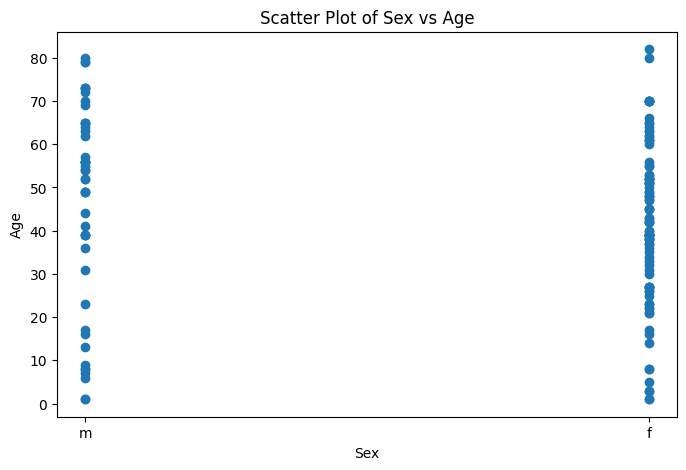

In [281]:
#scatter plot of age and sex
plt.figure(figsize=(8,5))
surg_data['Sex_num'] = surg_data['Sex'].map({'m': 0, 'f': 1})

plt.scatter(surg_data['Sex_num'], surg_data['Age'])

plt.xticks([0, 1], ['m', 'f'])
plt.xlabel('Sex')
plt.ylabel('Age')
plt.title('Scatter Plot of Sex vs Age')

plt.show()